## STEP 1 :Import Libraries  ##

In [3]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt 
import seaborn as sns
import re

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
import pandas as pd

df = pd.read_csv(
    "../data/spam.csv",
    sep="\t",
    header=None,
    names=["label", "text"],
    encoding="latin-1"
)

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.columns


Index(['label', 'text'], dtype='object')

## STEP 2: Data Exploration ##


In [6]:
## DATASET SIZE AND STRUCTURE ##
print("Shape of dataset:", df.shape)
print("\nDataset info:")
print(df.info())

Shape of dataset: (5572, 2)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


## STEP 3: VISUAL CHECK ##

In [7]:
## LABEL COUNTS ##
print("\nClass distribution:")
print(df["label"].value_counts())


Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
## MISSING VALES AND DUPLICATES ##
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
label    0
text     0
dtype: int64

Duplicate rows:
403


C:\Users\saksh\AppData\Local\Temp\ipykernel_21968\58428836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="Set2")


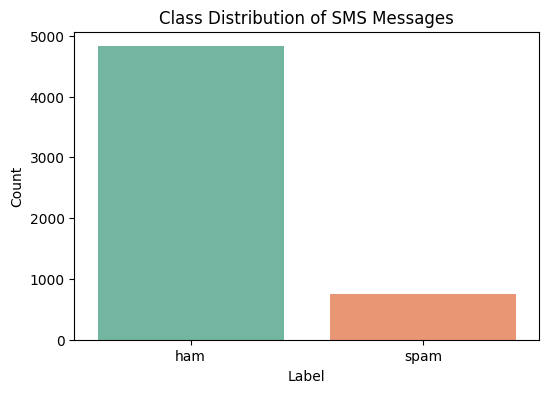

In [9]:
## VISUAL CHECK ##
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", palette="Set2")
plt.title("Class Distribution of SMS Messages")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [10]:
## CHECKING MESSAGE LENGTH ## 
df["message_length"] = df["text"].apply(len)

print(df["message_length"].describe())

count    5572.000000
mean       80.616296
std        60.015593
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: message_length, dtype: float64


## STEP 4 : DATA CLEANING ##

In [11]:
# Check for missing values #
print("Missing values before dropping:")
print(df.isnull().sum())

Missing values before dropping:
label             0
text              0
message_length    0
dtype: int64


In [12]:
# Drop duplicates #
print(f"Duplicate rows before dropping: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicate rows after dropping: {df.duplicated().sum()}")

Duplicate rows before dropping: 403
Duplicate rows after dropping: 0


In [13]:
#  Remove rows with missing text #
df = df.dropna(subset=["text"])

In [14]:
#  Define a clean_text function #
def clean_text(text):
    # to lower case
    text = text.lower()
    # remove digits and special characters, keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # remove extra whitespace
    text = " ".join(text.split())
    return text
df["cleaned_text"] = df["text"].apply(clean_text)


In [15]:
#  Quick check after cleaning #
print("\nAfter cleaning:")
print(df[["text", "cleaned_text"]].head(5))



After cleaning:
                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                        cleaned_text  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in a wkly comp to win fa cup final ...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  


## Step 5: train-test split and TF-IDF vectorization ##


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# features and labels
X = df["cleaned_text"]
y = df["label"]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

Train size: 4135
Test size: 1034
TF-IDF train shape: (4135, 5000)
TF-IDF test shape: (1034, 5000)


## Step 6: model training and evaluation ##

Accuracy: 0.9700193423597679

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       1.00      0.76      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



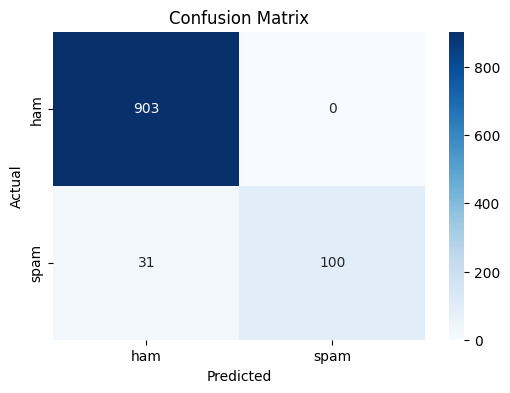

In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# train the model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# predictions
y_pred = model.predict(X_test_tfidf)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 7: make a prediction function ## 


In [18]:
def predict_message(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0]
    return prediction, probability

sample_text = "Congratulations! You won a free ticket. Click the link now."
pred, prob = predict_message(sample_text)
print("Prediction:", pred)
print("Probabilities:", prob)

Prediction: spam
Probabilities: [0.22010453 0.77989547]


In [21]:
import os
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

os.makedirs("models", exist_ok=True)

X = df["cleaned_text"]
y = df["label"]

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X_tfidf = tfidf.fit_transform(X)

model = MultinomialNB()
model.fit(X_tfidf, y)

joblib.dump(tfidf, "models/tfidf_vectorizer.joblib")
joblib.dump(model, "models/spam_classifier.joblib")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
